<a href="https://colab.research.google.com/github/KhansaMahira/Project-Fraud-Rated-Prediction-on-Transaction-with-Time-Series/blob/main/FinalProjectDataScience_FraudDetection1MTransactions_Versi1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries and Data Collection

Source: https://www.kaggle.com/datasets/sergionefedov/fraud-detection-1m-transactions-7-fraud-types?select=time_series_stats.csv

A comprehensive synthetic financial fraud detection dataset covering credit card and digital payment transactions from 2022-2024.

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.9 MB/s eta 0:00:00


In [ ]:
!pip install prophet

In [ ]:
!pip install tensorflow

In [ ]:
import itertools
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
import kagglehub
path = kagglehub.dataset_download("sergionefedov/fraud-detection-1m-transactions-7-fraud-types")

Using Colab cache for faster access to the 'fraud-detection-1m-transactions-7-fraud-types' dataset.


In [ ]:
import pandas as pd
import os

# List files in the directory to find the CSV file
files = os.listdir(path)
print(files)

['network_edges.csv', 'fraud_patterns.csv', 'account_profiles.csv', 'time_series_stats.csv', 'transactions.csv']


In [ ]:
# csv_file = [f for f in files if f.endswith('.csv')][0]

# Construct the full path to the CSV file
csv_path = os.path.join(path, 'time_series_stats.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_path)

In [ ]:
df.head()

,hour,transaction_count,fraud_count,total_amount,avg_amount,avg_ip_risk,fraud_rate,hour_of_day,day_of_week,is_weekend
0,2022-01-01 00:00:00,40,1,9341.66,233.54,19.92,0.025000,0,5,1
1,2022-01-01 01:00:00,43,0,6295.77,146.41,20.32,0.000000,1,5,1
2,2022-01-01 02:00:00,41,1,10763.95,262.54,22.13,0.024390,2,5,1
3,2022-01-01 03:00:00,34,0,9354.50,275.13,22.00,0.000000,3,5,1
4,2022-01-01 04:00:00,39,2,5897.09,151.21,25.87,0.051282,4,5,1


# Data Preparation

In [ ]:
# Convert the 'hour' string/object column to datetime
df["hour"] = pd.to_datetime(df["hour"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26280 entries, 0 to 26279
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   hour               26280 non-null  datetime64[ns]
 1   transaction_count  26280 non-null  int64         
 2   fraud_count        26280 non-null  int64         
 3   total_amount       26280 non-null  float64       
 4   avg_amount         26280 non-null  float64       
 5   avg_ip_risk        26280 non-null  float64       
 6   fraud_rate         26280 non-null  float64       
 7   hour_of_day        26280 non-null  int64         
 8   day_of_week        26280 non-null  int64         
 9   is_weekend         26280 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(5)
memory usage: 2.0 MB


In [ ]:
df.shape

(26280, 10)

## Data Integrity & Time Coverage

In [ ]:
# Check time range
print("Start:", df["hour"].min())
print("End  :", df["hour"].max())
print("Duration:", df["hour"].max() - df["hour"].min())

# Check frequency
time_diff = df["hour"].sort_values().diff().value_counts()
print("\nTime interval:")
print(time_diff.head())

# Check duplicated timestamps
print("\nDuplicated timestamps:", df["hour"].duplicated().sum())

# Check missing timestamps
expected_hours = pd.date_range(
    start=df["hour"].min(),
    end=df["hour"].max(),
    freq="h"
)

missing_hours = expected_hours.difference(df["hour"])

print("Expected observations:", len(expected_hours))
print("Actual observations:", len(df))
print("Missing timestamps:", len(missing_hours))

Start: 2022-01-01 00:00:00
End  : 2024-12-30 23:00:00
Duration: 1094 days 23:00:00

Time interval:
hour
0 days 01:00:00    26279
Name: count, dtype: int64

Duplicated timestamps: 0
Expected observations: 26280
Actual observations: 26280
Missing timestamps: 0


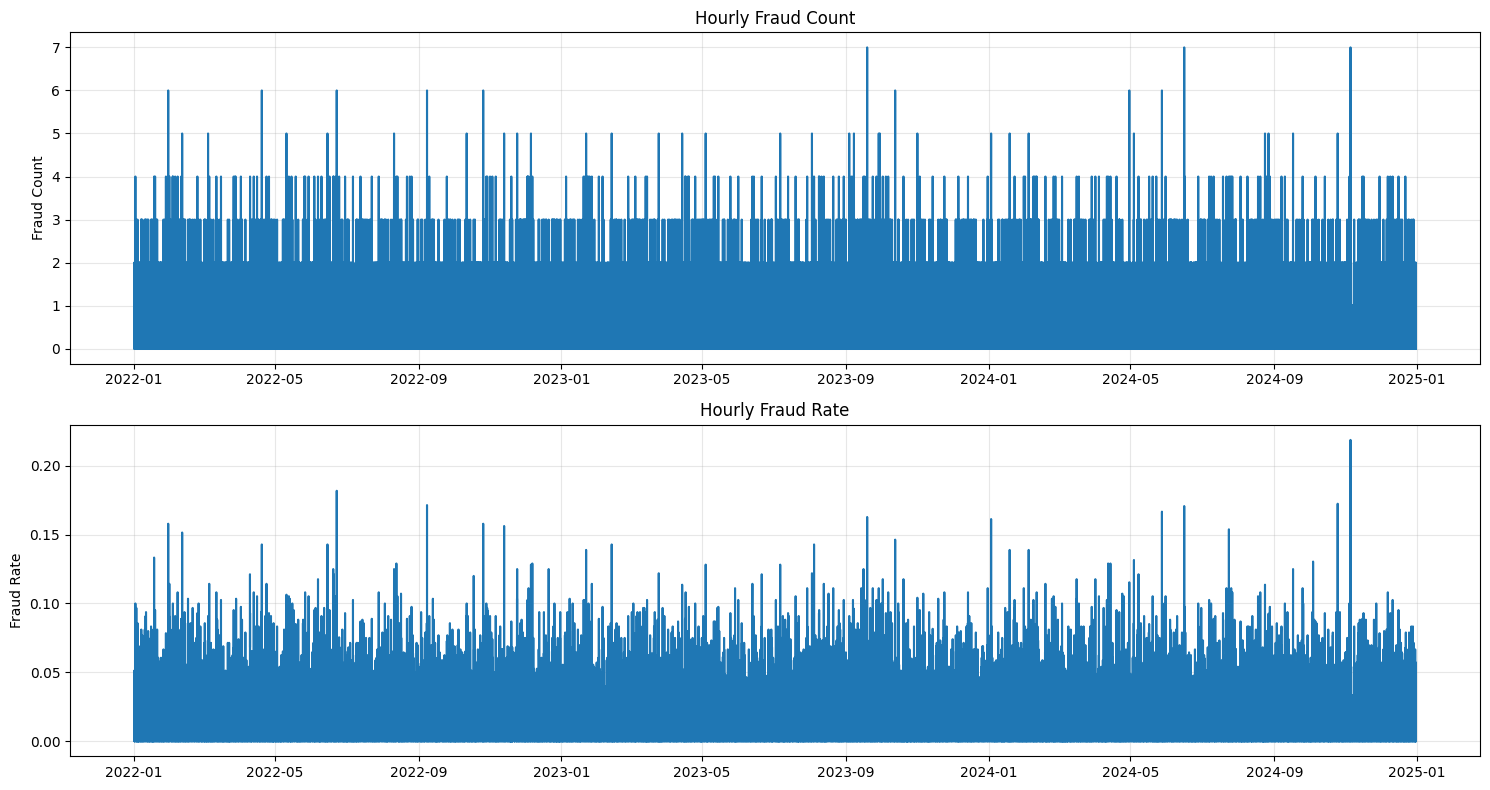

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(
    df["hour"],
    df["fraud_count"]
)

axes[0].set_title("Hourly Fraud Count")
axes[0].set_ylabel("Fraud Count")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    df["hour"],
    df["fraud_rate"]
)

axes[1].set_title("Hourly Fraud Rate")
axes[1].set_ylabel("Fraud Rate")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exploratory Data Analysis

In [ ]:
df.describe()

,hour,transaction_count,fraud_count,total_amount,avg_amount,avg_ip_risk,fraud_rate,hour_of_day,day_of_week,is_weekend
count,26280,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000
mean,2023-07-02 11:30:00,38.051750,0.652321,6991.562544,183.751070,21.606374,0.017130,11.500000,3.001826,0.286758
min,2022-01-01 00:00:00,15.000000,0.000000,1661.770000,66.750000,11.480000,0.000000,0.000000,0.000000,0.000000
25%,2022-10-01 17:45:00,34.000000,0.000000,5410.165000,148.105000,19.760000,0.000000,5.750000,1.000000,0.000000
50%,2023-07-02 11:30:00,38.000000,0.000000,6684.720000,176.025000,21.530000,0.000000,11.500000,3.000000,0.000000
75%,2024-04-01 05:15:00,42.000000,1.000000,8230.637500,210.505000,23.360000,0.027778,17.250000,5.000000,1.000000
max,2024-12-30 23:00:00,67.000000,7.000000,33763.350000,985.100000,34.680000,0.218750,23.000000,6.000000,1.000000
std,NaN,6.185519,0.846763,2264.604312,52.143961,2.685101,0.022284,6.922318,2.002319,0.452256


## Korelasi antar variabel numerik

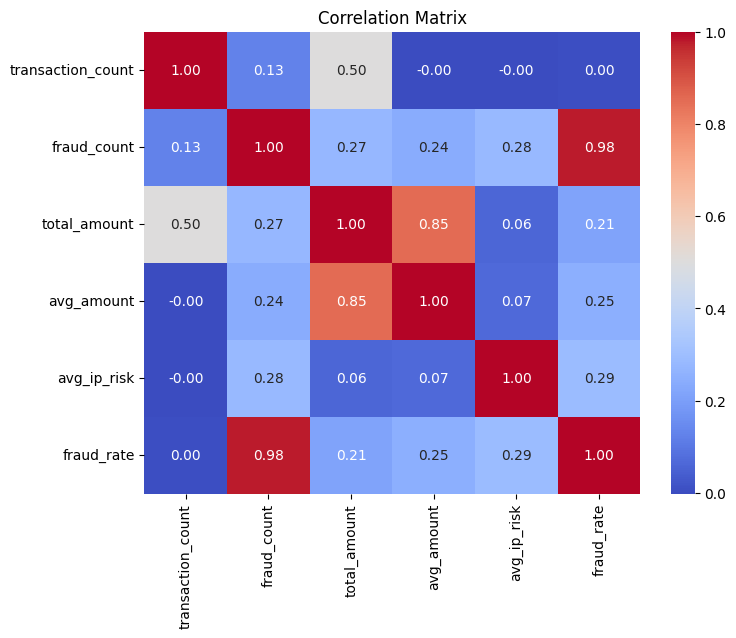

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
corr = df[['transaction_count','fraud_count','total_amount','avg_amount','avg_ip_risk','fraud_rate']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Berdasarkan matriks korelasi, maka hubungan antara fraud_rate sangat berkorelasi dengan fraud_count sebesar 0.98. Selain itu hubungan yang sangat berkorelasi terdapat pada avg_amount dan total_amount sebesar 0.85.

Atribut lain yang memiliki korelasi lemah dengan fraud_rate adalah atribut avg_ip_risk (0.29), avg_amount (0.25), dan total_amount (0.21).

## Distribusi Target fraud_rate

In [ ]:
df["fraud_rate"].describe()

,fraud_rate
count,26280.000000
mean,0.017130
std,0.022284
min,0.000000
25%,0.000000
50%,0.000000
75%,0.027778
max,0.218750


In [ ]:
print("Skewness:", df['fraud_rate'].skew())

Skewness: 1.478400530201827


Nilai skewness sebesar 1.4784 menunjukkan bahwa distribusi fraud_rate right-skewed, dengan mayoritas nilai berada pada tingkat rendah dan sebagian kecil observasi memiliki fraud rate yang jauh lebih tinggi.

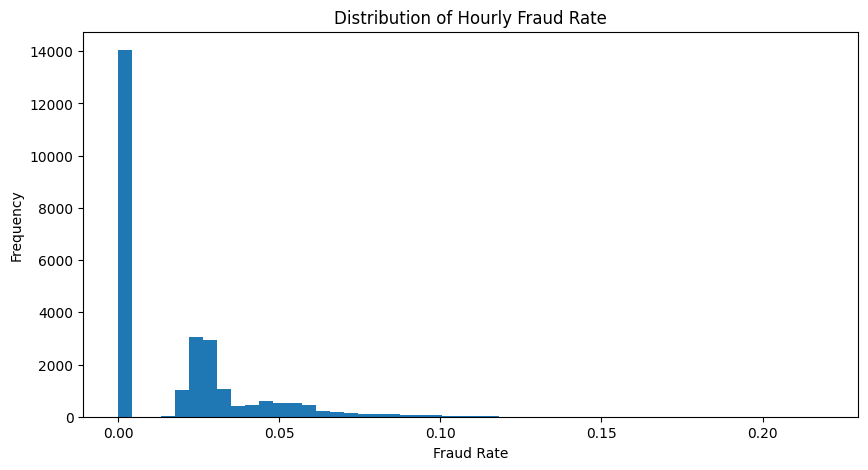

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df["fraud_rate"], bins=50)

plt.title("Distribution of Hourly Fraud Rate")
plt.xlabel("Fraud Rate")
plt.ylabel("Frequency")

plt.show()

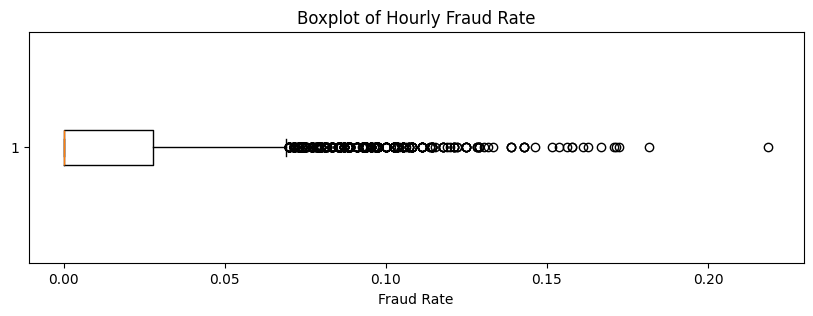

In [ ]:
plt.figure(figsize=(10, 3))

plt.boxplot(df["fraud_rate"], vert=False)

plt.title("Boxplot of Hourly Fraud Rate")
plt.xlabel("Fraud Rate")

plt.show()

Distribusi fraud_rate dalam jam bersifat right-skewed, dengan mayoritas observasi memiliki fraud rate rendah yaitu sekitar 0.02 hingga 0.06 dan hanya sebagian kecil observasi yang menunjukkan tingkat fraud yang tinggi.

## Cek konsistensi fraud_count vs fraud_rate vs transaction_count

In [ ]:
implied_rate = df['fraud_count'] / df['transaction_count']
diff = (implied_rate - df['fraud_rate']).abs()
print("Max deviasi:", diff.max())

Max deviasi: 4.897959183652878e-07


Berdasarkan perhitungan di atas, absolut dari fraud_count / transaction_count menghasilkan perbedaan angka dengan fraud_rate dengan maksimal berupa $4.898 \times 10^{-7}$ atau sekitar 0.0000004898.

## Analisis Pola Kalender & Musiman Transaksi

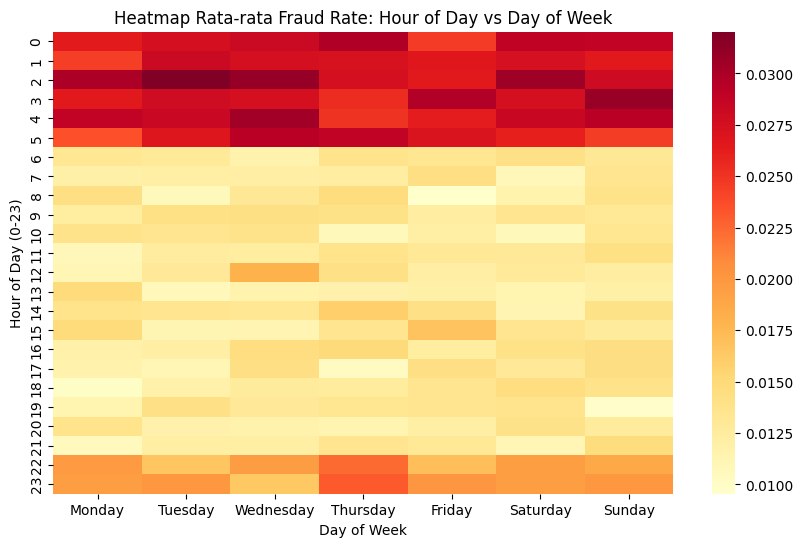

In [ ]:
import seaborn as sns

# Map day numbers to names
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
             4: 'Friday', 5: 'Saturday', 6: 'Sunday'}

df['day_of_week_name'] = df['day_of_week'].map(day_names)

# Heatmap Hour vs Day of Week
pivot_fraud = df.pivot_table(index='hour_of_day', columns='day_of_week_name', values='fraud_rate', aggfunc='mean')

# Reorder columns so they appear Monday -> Sunday instead of alphabetically
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_fraud = pivot_fraud.reindex(columns=ordered_days)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_fraud, cmap='YlOrRd', annot=False)
plt.title("Heatmap Rata-rata Fraud Rate: Hour of Day vs Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Hour of Day (0-23)")
plt.show()

Berdasarkan heatmap di atas, fraud rate yang tinggi menunjukkan fraud paling banyak terjadi pada pukul 0 hingga pukul 5 pagi setiap hari. Sebaliknya, transaksi fraud sedikit terjadi pada pukul 6 hingga pukul 21.

## Uji stasioneritas (ADF (Augmented Dickey-Fuller) & KPSS (Kwiatkowski–Phillips–Schmidt–Shin))

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

adf_result = adfuller(df['fraud_rate'])
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"ADF p-value: {adf_result[1]:.4f}")

kpss_result = kpss(df['fraud_rate'], regression='c')
print(f"KPSS p-value: {kpss_result[1]:.4f}")

ADF Statistic: -20.5545
ADF p-value: 0.0000
KPSS p-value: 0.1000


/tmp/ipykernel_1052/1227904950.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(df['fraud_rate'])
/tmp/ipykernel_1052/1227904950.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_result = kpss(df['fraud_rate'], regression='c')
/tmp/ipykernel_1052/1227904950.py:7: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a K

* ADF p-value ≤ 0.05 & KPSS p-value > 0.05	0✅ Stationary (both agree)
* ADF p-value > 0.05 & KPSS p-value ≤ 0.05	✅ Non-stationary (both agree)
* ADF p-value ≤ 0.05 & KPSS p-value ≤ 0.05	⚠️ Conflicting — often "difference-stationary" (trend-stationary once detrended, but not level-stationary); or check for structural breaks
* ADF p-value > 0.05 & KPSS p-value > 0.05	⚠️ Conflicting — insufficient evidence either way; series may be borderline, or you need more data/different test specification

Karena nilai ADF bernilai 0 (<= 0.05) dan nilai KPSS bernilai 0.1 (> 0.05) maka fraud_rate bersifat stationary. Properti fraud_rate berupa mean dan variance tetap konstan sepanjang waktu yang merupakan persyaratan inti dari model ARIMA dan SARIMA.

## Hubungan fraud_rate saat ini dengan periode sebelumnya melalui ACF (Autocorrelation Function) & PACF (Partial Autocorrelation Function)

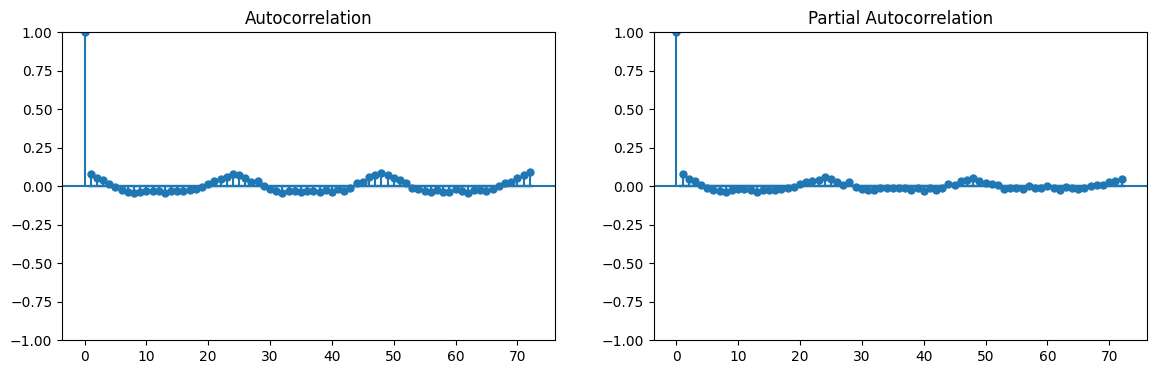

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['fraud_rate'], lags=72, ax=axes[0])
plot_pacf(df['fraud_rate'], lags=72, ax=axes[1])
plt.show()

lags=72 berarti grafik akan menampilkan 72 periode sebelumnya atau setara dengan 72 jam sebelumnya berdasarkan 1 hari merupakan 1 periode.

ACF bisa melihat hubungan langsung (periode t dan t-1) dan tidak langsung (contoh periode t dan t-2).

PACF mengukur hubungan langsung antara fraud_rate(t) dan fraud_rate(t-k) setelah pengaruh lag-lag sebelumnya dikontrol.

ACF menunjukkan pola siklik/bergelombang, sedangkan PACF tidak menunjukkan spike besar yang tajam pada lag tertentu. Autocorrelation yang dimiliki fraud_rate merupakan pola temporal yang lemah tetapi berulang pada jangka pendek 24 lag atau 24 jam.

PACF tidak mempunyai spike besar yang berarti tidak ada AR structure yang sangat kuat tetapi juga memperlihatkan gelombang yang terkait struktur periodik. Selain itu, PACF tidak menunjukkan titik potong yang tegas pada lag tertentu, yang mengisyaratkan bahwa struktur autoregresif sederhana tidak mendominasi secara kuat.

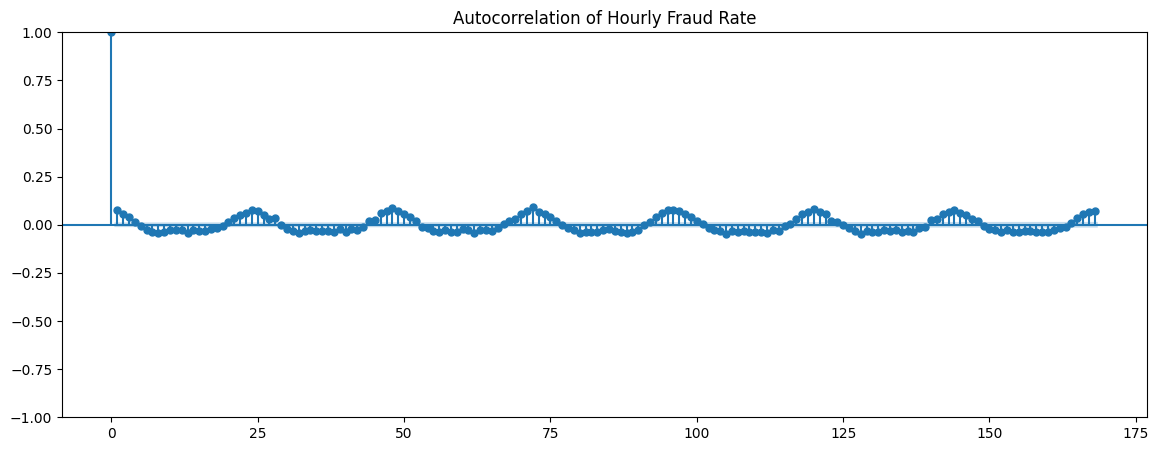

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14, 5))

plot_acf(
    df["fraud_rate"],
    lags=168,
    ax=plt.gca()
)

plt.title("Autocorrelation of Hourly Fraud Rate")

plt.show()

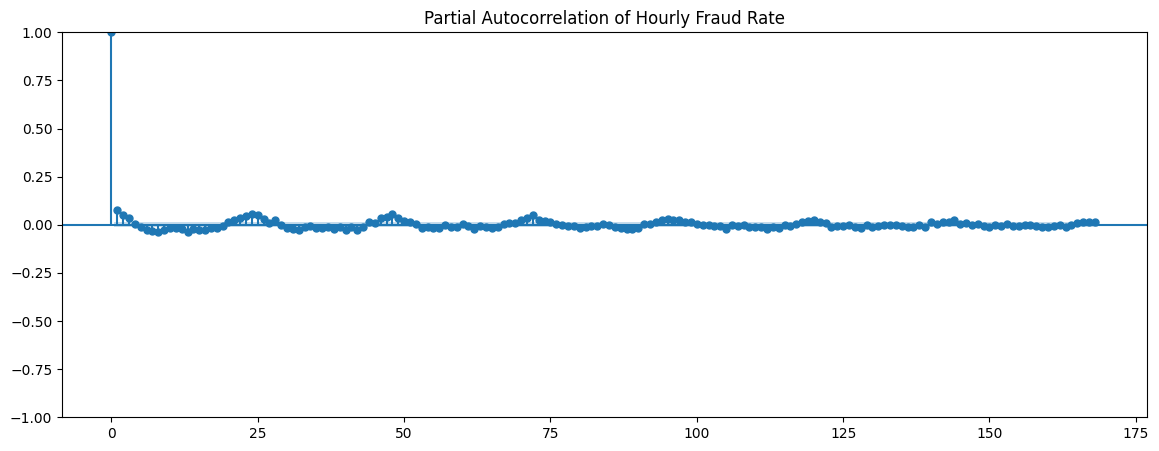

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(14, 5))

plot_pacf(
    df["fraud_rate"],
    lags=168,
    ax=plt.gca()
)

plt.title("Partial Autocorrelation of Hourly Fraud Rate")

plt.show()

## Pola berdasarkan hour_of_day, day_of_week, is_weekend

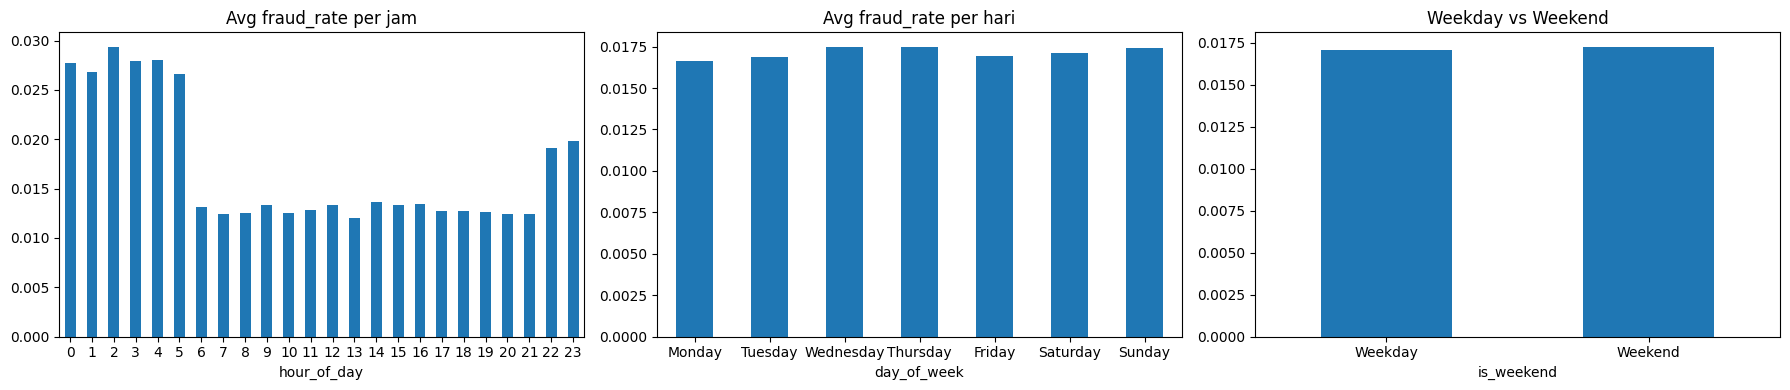

In [ ]:
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
             4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
weekend_names = {0: 'Weekday', 1: 'Weekend'}

fig, axes = plt.subplots(1, 3, figsize=(18,4))

df.groupby('hour_of_day')['fraud_rate'].mean().plot(kind='bar', ax=axes[0], title='Avg fraud_rate per jam')

df.groupby('day_of_week')['fraud_rate'].mean().rename(index=day_names).plot(
    kind='bar', ax=axes[1], title='Avg fraud_rate per hari'
)

df.groupby('is_weekend')['fraud_rate'].mean().rename(index=weekend_names).plot(
    kind='bar', ax=axes[2], title='Weekday vs Weekend'
)

for ax in axes:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

Berdasarkan rata-rata fraud_rate berdasarkan jam, fraud tinggi terjadi pada jam 0 hingga 5, sedang pada jam 22 hingga 23, dan sedikit pada jam 6 hingga 21. Namun, tren tidak jauh berbeda berdasarkan rata-rata fraud_rate sehari dan weekday atau weekend.

## Deteksi outlier/anomali pada fraud_rate

In [ ]:
from scipy import stats
z_scores = np.abs(stats.zscore(df['fraud_rate']))
anomalies = df[z_scores > 3]
print(f"Jumlah potensi anomali (z>3): {len(anomalies)}")
anomalies[['hour','fraud_rate']].head(10)

Jumlah potensi anomali (z>3): 355


,hour,fraud_rate
26,2022-01-02 02:00:00,0.100000
45,2022-01-02 21:00:00,0.096774
70,2022-01-03 22:00:00,0.085714
235,2022-01-10 19:00:00,0.090909
244,2022-01-11 04:00:00,0.093750
410,2022-01-18 02:00:00,0.133333
430,2022-01-18 22:00:00,0.095238
699,2022-01-30 03:00:00,0.157895
718,2022-01-30 22:00:00,0.090909
722,2022-01-31 02:00:00,0.114286


Dalam distribusi normal standar, sekitar 99.7% data berada dalam rentang $\pm 3$ standar deviasi. Data dengan $\vert{}z\vert{} > 3$ berada di luar rentang umum ini, sehingga diklasifikasikan sebagai anomali atau data yang sangat tidak biasa.

Oleh karena itu, jumlah potensi anomali yang dimiliki fraud_rate sebanyak 355 data dari 26,280 atau setara dengan 1.35%.

In [ ]:
def detect_outliers_iqr(series, k=1.5):
    """
    Deteksi outlier menggunakan metode IQR (Interquartile Range).

    series : pandas Series atau array 1D nilai fraud_rate
    k      : multiplier IQR untuk menentukan batas (default 1.5, standar Tukey's fence)
             gunakan k=3.0 kalau ingin lebih ketat/hanya outlier ekstrem

    Return: DataFrame dengan kolom value, is_outlier, batas bawah/atas
    """
    s = pd.Series(series).reset_index(drop=True)

    Q1 = s.quantile(0.25)
    Q2 = s.quantile(0.50)  # median
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR

    result = pd.DataFrame({
        "value": s,
        "is_outlier": (s < lower_bound) | (s > upper_bound),
    })

    print(f"Q1  : {Q1:.6f}")
    print(f"Q2  (median): {Q2:.6f}")
    print(f"Q3  : {Q3:.6f}")
    print(f"IQR : {IQR:.6f}")
    print(f"Batas bawah : {lower_bound:.6f}")
    print(f"Batas atas  : {upper_bound:.6f}")
    print(f"Jumlah outlier: {result['is_outlier'].sum()} dari {len(s)} data ({result['is_outlier'].mean()*100:.2f}%)")

    return result, lower_bound, upper_bound

# contoh pemakaian di seluruh data
outlier_df, lower, upper = detect_outliers_iqr(df["fraud_rate"], k=1.5)

Q1  : 0.000000
Q2  (median): 0.000000
Q3  : 0.027778
IQR : 0.027778
Batas bawah : -0.041667
Batas atas  : 0.069445
Jumlah outlier: 804 dari 26280 data (3.06%)


## Time-Series Decomposition / Seasonality

In [ ]:
SEQ_LEN = 24

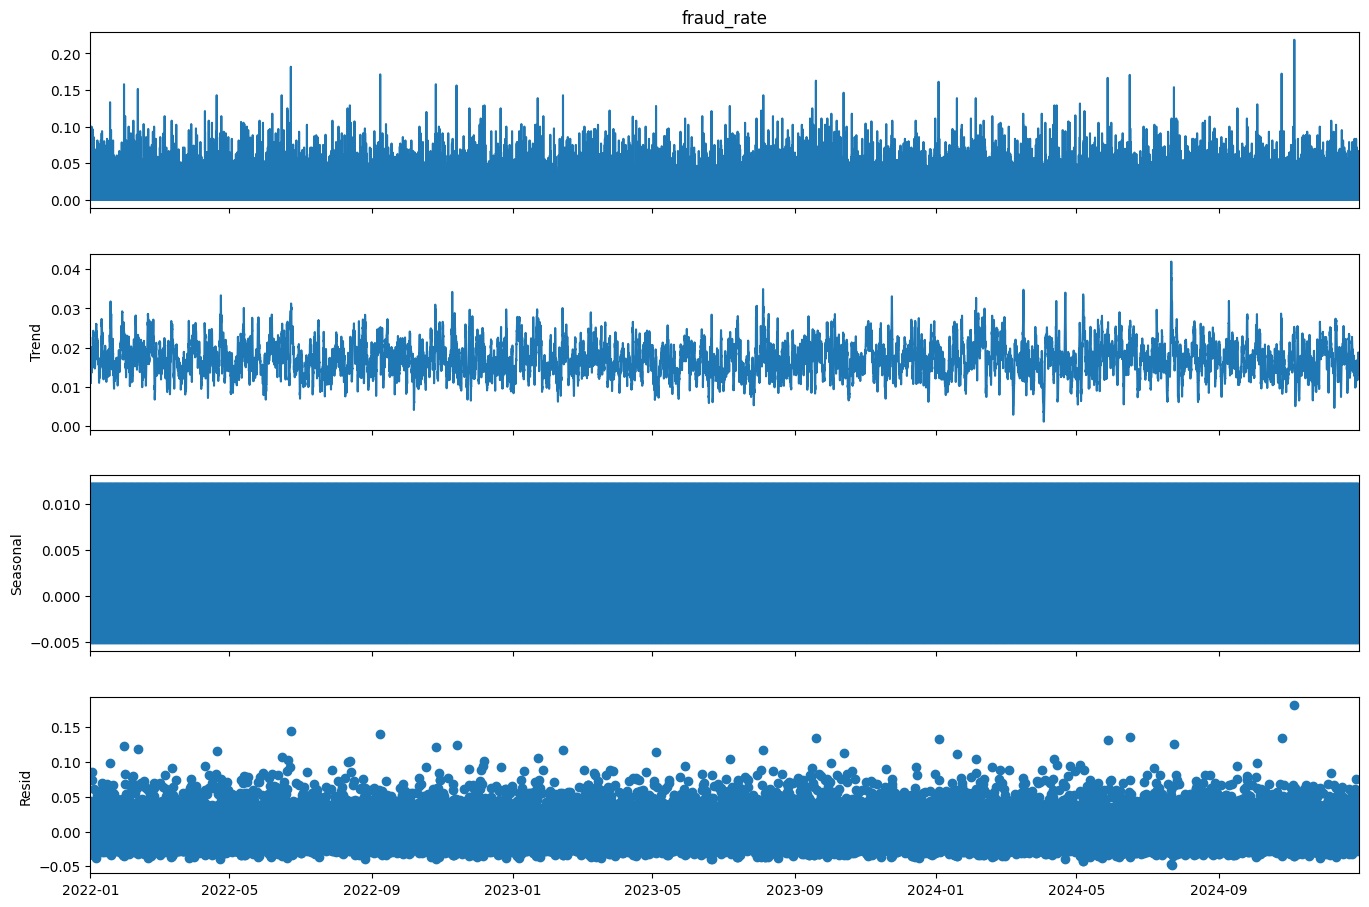

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = df.set_index("hour")["fraud_rate"]

decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=24
)

fig = decomposition.plot()
fig.set_size_inches(15, 10)

plt.show()

Dekomposisi menunjukkan bahwa fraud_rate memiliki trend yang relatif stabil, pola musiman 24 jam, serta residual yang cukup fluktuatif dengan beberapa lonjakan. Fraud rate memiliki beberapa spike tinggi hingga lebih dari 0,10 yang tidak sepenuhnya dijelaskan oleh trend dan seasonal, sehingga muncul sebagai residual positif yang besar.

##  Hourly Seasonality

In [ ]:
hourly_pattern = (
    df.groupby("hour_of_day")["fraud_rate"]
      .agg(["mean", "median", "std"])
)

print(hourly_pattern)

                 mean    median       std
hour_of_day                              
0            0.027769  0.025641  0.026286
1            0.026862  0.025641  0.026514
2            0.029369  0.026316  0.028806
3            0.027940  0.025641  0.027753
4            0.028078  0.025000  0.027610
5            0.026601  0.025000  0.026890
6            0.013145  0.000000  0.018565
7            0.012445  0.000000  0.017866
8            0.012527  0.000000  0.018626
9            0.013360  0.000000  0.018604
10           0.012555  0.000000  0.018476
11           0.012792  0.000000  0.017965
12           0.013356  0.000000  0.018473
13           0.012004  0.000000  0.018257
14           0.013648  0.000000  0.018377
15           0.013378  0.000000  0.018438
16           0.013457  0.000000  0.019237
17           0.012699  0.000000  0.018342
18           0.012703  0.000000  0.018451
19           0.012633  0.000000  0.018027
20           0.012453  0.000000  0.018307
21           0.012433  0.000000  0

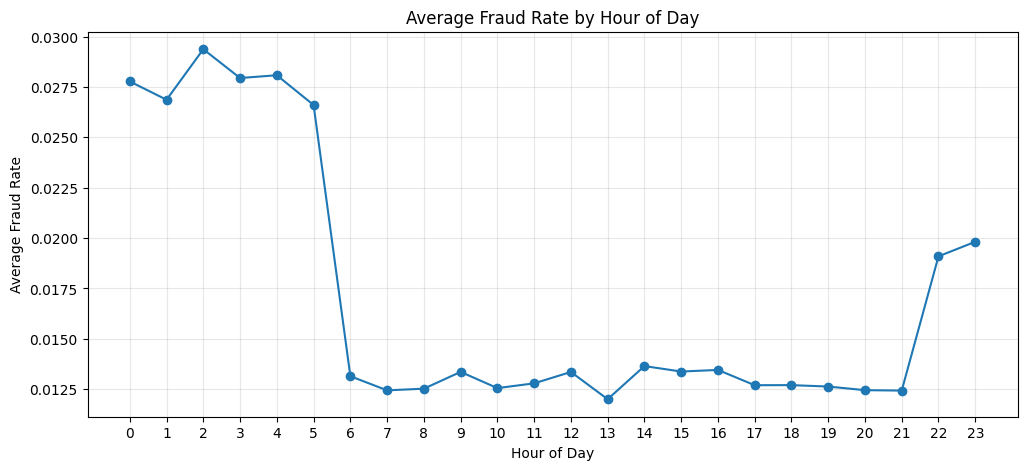

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern["mean"],
    marker="o"
)

plt.xticks(range(24))
plt.title("Average Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fraud Rate")
plt.grid(True, alpha=0.3)

plt.show()

Berdasarkan rata-rata fraud rate untuk setiap jam setiap hari, rata-rata fraud rate mencapai lebih dari 0.025 pada pukul 0 hingga 5 lalu melonjak turun yang kurang dari 0.015 pada pukul 6 hingga 21 sebelum meningkat kembali pada pukul 22 hingga 23 yang di antara 0.0175 dan 0.02. Hal ini menandakan fraud rate tinggi pada malam hari.

## Day-of-Week & Weekend Analysis

### Fraud rate berdasarkan hari

In [ ]:
dow_pattern = (
    df.groupby("day_of_week")["fraud_rate"]
      .agg(["mean", "median", "std"])
)

print(dow_pattern)

                 mean  median       std
day_of_week                            
0            0.016618     0.0  0.021755
1            0.016852     0.0  0.022428
2            0.017486     0.0  0.022456
3            0.017491     0.0  0.022549
4            0.016952     0.0  0.021965
5            0.017101     0.0  0.021992
6            0.017411     0.0  0.022830


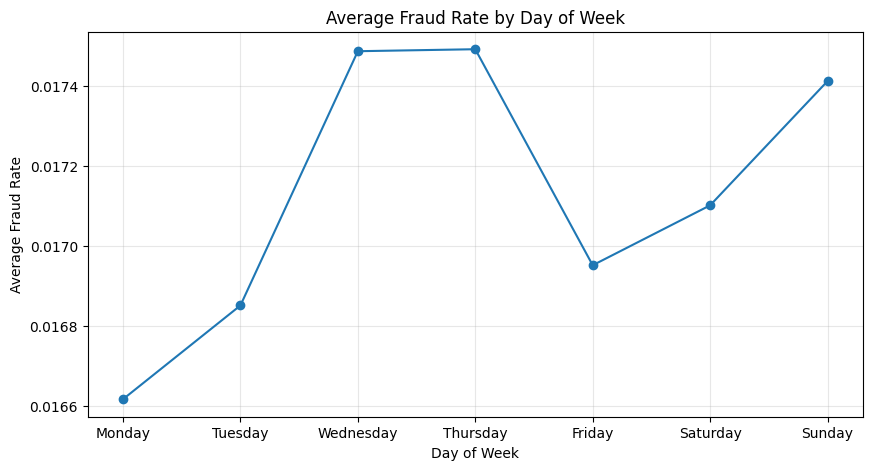

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    dow_pattern.index,
    dow_pattern["mean"],
    marker="o"
)

plt.xticks(
    range(7),
    ["Monday", "Tuesday", "Wednesday",
     "Thursday", "Friday", "Saturday", "Sunday"]
)

plt.title("Average Fraud Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Fraud Rate")
plt.grid(True, alpha=0.3)

plt.show()

Berdasarkan rata-rata fraud rate harian dalam seminggu, rating fraud terbanyak melebihi 0.0174 pada hari Rabu, Kamis dan Minggu, sedangkan terendah yaitu di antara 0.0166 dan 0.0167 pada hari Senin.

### Weekend vs weekday

In [ ]:
weekend_pattern = (
    df.groupby("is_weekend")["fraud_rate"]
      .agg(["mean", "median", "std", "count"])
)

print(weekend_pattern)

                mean  median       std  count
is_weekend                                   
0           0.017079     0.0  0.022233  18744
1           0.017256     0.0  0.022414   7536


Berdasarkan rata-rata fraud rate pada hari kerja atau akhir pekan, fraud rate lebih besar terjadi pada akhir pekan walau memiliki selisih yang kecil dengan hari kerja.

<Figure size 700x500 with 0 Axes>

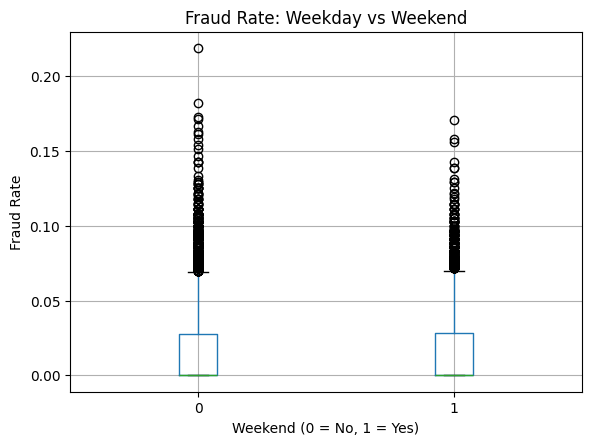

In [ ]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="fraud_rate",
    by="is_weekend"
)

plt.title("Fraud Rate: Weekday vs Weekend")
plt.suptitle("")
plt.xlabel("Weekend (0 = No, 1 = Yes)")
plt.ylabel("Fraud Rate")

plt.show()

## Rolling Statistics

In [ ]:
df_eda = df.copy()

df_eda["fraud_rate_rolling_24"] = (
    df_eda["fraud_rate"]
    .rolling(24)
    .mean()
)

df_eda["fraud_rate_rolling_168"] = (
    df_eda["fraud_rate"]
    .rolling(168)
    .mean()
)

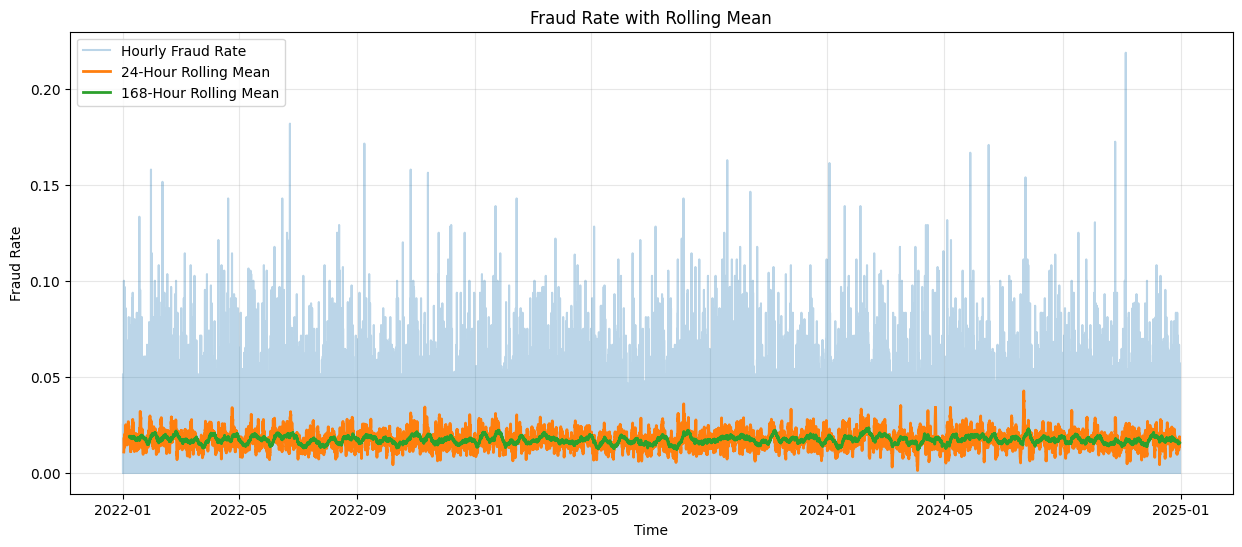

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    df_eda["hour"],
    df_eda["fraud_rate"],
    alpha=0.3,
    label="Hourly Fraud Rate"
)

plt.plot(
    df_eda["hour"],
    df_eda["fraud_rate_rolling_24"],
    label="24-Hour Rolling Mean",
    linewidth=2
)

plt.plot(
    df_eda["hour"],
    df_eda["fraud_rate_rolling_168"],
    label="168-Hour Rolling Mean",
    linewidth=2
)

plt.title("Fraud Rate with Rolling Mean")
plt.xlabel("Time")
plt.ylabel("Fraud Rate")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Fraud rate aktual memiliki volatilitas dan spike yang tinggi, tetapi rata-rata bergerak 24 jam dan 7 hari menunjukkan bahwa tingkat fraud secara umum relatif stabil sepanjang periode pengamatan. Rolling mean 24 jam lebih responsif terhadap perubahan jangka pendek, sedangkan rolling mean 168 jam memberikan gambaran tren yang lebih halus.

# Data Preprocessing

## Handling Missing Values

In [ ]:
df.isnull().sum()

,0
hour,0
transaction_count,0
fraud_count,0
total_amount,0
avg_amount,0
avg_ip_risk,0
fraud_rate,0
hour_of_day,0
day_of_week,0
is_weekend,0


## Handling Duplicated Values

In [ ]:
df.duplicated().sum()

np.int64(0)

## Descriptive Statistics of dataframe

In [ ]:
df = df.sort_values("hour").reset_index(drop=True)
df.describe()

,hour,transaction_count,fraud_count,total_amount,avg_amount,avg_ip_risk,fraud_rate,hour_of_day,day_of_week,is_weekend
count,26280,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000,26280.000000
mean,2023-07-02 11:30:00,38.051750,0.652321,6991.562544,183.751070,21.606374,0.017130,11.500000,3.001826,0.286758
min,2022-01-01 00:00:00,15.000000,0.000000,1661.770000,66.750000,11.480000,0.000000,0.000000,0.000000,0.000000
25%,2022-10-01 17:45:00,34.000000,0.000000,5410.165000,148.105000,19.760000,0.000000,5.750000,1.000000,0.000000
50%,2023-07-02 11:30:00,38.000000,0.000000,6684.720000,176.025000,21.530000,0.000000,11.500000,3.000000,0.000000
75%,2024-04-01 05:15:00,42.000000,1.000000,8230.637500,210.505000,23.360000,0.027778,17.250000,5.000000,1.000000
max,2024-12-30 23:00:00,67.000000,7.000000,33763.350000,985.100000,34.680000,0.218750,23.000000,6.000000,1.000000
std,NaN,6.185519,0.846763,2264.604312,52.143961,2.685101,0.022284,6.922318,2.002319,0.452256


## Penetapan kolom target

In [ ]:
target_col = "fraud_rate"
series = df[[target_col]].values

In [ ]:
series

array([[0.025   ],
       [0.      ],
       [0.02439 ],
       ...,
       [0.      ],
       [0.057143],
       [0.      ]])

# Data scaling dan train test split

In [ ]:
SEQ_LEN = 24

In [ ]:
# 80/20 CHRONOLOGICAL TRAIN-TEST SPLIT

split_idx = int(len(series) * 0.80)

train_raw = series[:split_idx]
test_raw = series[split_idx:]

test_dates = df["hour"].iloc[split_idx:].reset_index(drop=True)

print(f"Train observations: {len(train_raw)}")
print(f"Test observations : {len(test_raw)}")

Train observations: 21024
Test observations : 5256


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_raw)
scaled_train = scaler.transform(train_raw)
scaled_test = scaler.transform(test_raw)

# Create LSTM sequences

In [ ]:
def create_sequences(data, seq_len):
    X, y = [], []

    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i])

    return np.array(X), np.array(y)


X_train, y_train_scaled = create_sequences(
    scaled_train,
    SEQ_LEN
)

In [ ]:
# Buat sequence test
test_input = np.concatenate([
    scaled_train[-SEQ_LEN:],
    scaled_test
])

X_test, y_test_scaled = create_sequences(
    test_input,
    SEQ_LEN
)

In [ ]:
y_test_rescaled = scaler.inverse_transform(
    y_test_scaled
).flatten()

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"Test observations: {len(y_test_rescaled)}")

X_train: (21000, 24, 1)
X_test : (5256, 24, 1)
Test observations: 5256


# Model Training and Hyperparameter Tuning

In [ ]:
test_preds = {}

In [ ]:
final_models = {}

## LSTM

In [ ]:
import keras_tuner as kt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam


def build_lstm_model(hp):

    model = Sequential([
        LSTM(
            units=hp.Int(
                "units",
                min_value=32,
                max_value=128,
                step=32
            ),
            activation="tanh",
            input_shape=(SEQ_LEN, 1)
        ),

        Dropout(
            hp.Float(
                "dropout",
                min_value=0.0,
                max_value=0.3,
                step=0.1
            )
        ),

        Dense(1)
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice(
                "learning_rate",
                [0.001, 0.005, 0.01]
            )
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_lstm_model,
    objective="val_mae",
    max_trials=10,
    directory="lstm_tuning",
    project_name="fraud_rate"
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
tuner.search(
    X_train,
    y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Trial 10 Complete [00h 06m 30s]
val_mae: 0.09935987740755081

Best val_mae So Far: 0.09825634211301804
Total elapsed time: 01h 25m 45s


In [ ]:
best_hp = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

print("Best Hyperparameters:")
print("Units         :", best_hp.get("units"))
print("Dropout       :", best_hp.get("dropout"))
print("Learning Rate :", best_hp.get("learning_rate"))

Best Hyperparameters:
Units         : 96
Dropout       : 0.1
Learning Rate : 0.01


In [ ]:
final_lstm = Sequential([
    LSTM(
        units=best_hp.get("units"),
        activation="tanh",
        input_shape=(SEQ_LEN, 1)
    ),

    Dropout(
        best_hp.get("dropout")
    ),

    Dense(1)
])

final_lstm.compile(
    optimizer=Adam(
        learning_rate=best_hp.get("learning_rate")
    ),
    loss="mse",
    metrics=["mae"]
)

# Train on ALL 80% training data
final_lstm.fit(
    X_train,
    y_train_scaled,
    epochs=50,
    batch_size=32,
    shuffle=False,
    verbose=1
)

Epoch 1/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.0153 - mae: 0.1003
Epoch 2/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0150 - mae: 0.1000
Epoch 3/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0150 - mae: 0.1000
Epoch 4/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0150 - mae: 0.0999
Epoch 5/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0150 - mae: 0.0997
Epoch 6/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0149 - mae: 0.0995
Epoch 7/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0151 - mae: 0.0999
Epoch 8/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0152 - mae: 0.1003
Epoch 9/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0151 - mae: 0.1000
Epoch 10/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0150 - mae: 0.0998
Epoch 11/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.0150 - mae: 0.0997
Epoch 12/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0150 - mae: 0.0994
E

In [ ]:
y_pred_scaled = final_lstm.predict(
    X_test,
    verbose=0
)

y_pred = scaler.inverse_transform(
    y_pred_scaled
).flatten()

test_preds["LSTM"] = y_pred

In [ ]:
final_models["LSTM"] = final_lstm

## Holts-Winter

In [ ]:
# INTERNAL VALIDATION INSIDE THE 80% TRAINING DATA
tune_split = int(len(train_raw) * 0.80)

hw_tr = train_raw[:tune_split]
hw_val = train_raw[tune_split:]

hw_configs = [
    {"trend": "add", "damped_trend": True},
    {"trend": "add", "damped_trend": False},
    {"trend": None, "damped_trend": False},
]

best_hw_mae = float("inf")
best_hw_cfg = None

In [ ]:
for cfg in hw_configs:

    try:
        fit = ExponentialSmoothing(
            hw_tr,
            trend=cfg["trend"],
            seasonal="add",
            seasonal_periods=24,
            damped_trend=cfg["damped_trend"],
        ).fit()

        val_pred = fit.forecast(len(hw_val))

        mae = mean_absolute_error(hw_val, val_pred)

        print(
            f"Config: {cfg} | "
            f"Validation MAE: {mae:.6f}"
        )

        if mae < best_hw_mae:
            best_hw_mae = mae
            best_hw_cfg = cfg.copy()

    except Exception as e:
        print(f"Skipped {cfg}: {e}")

print("\nBest Holt-Winters Parameters:")
print(best_hw_cfg)
print(f"Best Validation MAE: {best_hw_mae:.6f}")

Config: {'trend': 'add', 'damped_trend': True} | Validation MAE: 0.017311
Config: {'trend': 'add', 'damped_trend': False} | Validation MAE: 0.017366
Config: {'trend': None, 'damped_trend': False} | Validation MAE: 0.017321

Best Holt-Winters Parameters:
{'trend': 'add', 'damped_trend': True}
Best Validation MAE: 0.017311


In [ ]:
# REFIT BEST MODEL ON ALL 80% TRAINING DATA
hw_fit = ExponentialSmoothing(
    train_raw,
    trend=best_hw_cfg["trend"],
    seasonal="add",
    seasonal_periods=24,
    damped_trend=best_hw_cfg["damped_trend"],
).fit()

# FORECAST THE SAME 20% TEST DATA
hw_pred = hw_fit.forecast(len(test_raw))

test_preds["Holt-Winters"] = hw_pred

In [ ]:
final_models["Holt-Winters"] = hw_fit

## ARIMA

In [ ]:
print("Tuning ARIMA...")

# INTERNAL VALIDATION INSIDE THE 80% TRAINING DATA
tune_split = int(len(train_raw) * 0.80)

arima_tr = train_raw[:tune_split]
arima_val = train_raw[tune_split:]

arima_orders = [
    (1, 0, 1),
    (2, 0, 1),
    (2, 0, 2),
    (3, 0, 1),
    (1, 1, 1),
]

best_arima_mae = float("inf")
best_arima_order = None

Tuning ARIMA...


In [ ]:
for order in arima_orders:

    try:
        fit = ARIMA(
            arima_tr,
            order=order
        ).fit()

        val_pred = fit.forecast(len(arima_val))

        mae = mean_absolute_error(
            arima_val,
            val_pred
        )

        print(
            f"Order: {order} | "
            f"Validation MAE: {mae:.6f}"
        )

        if mae < best_arima_mae:
            best_arima_mae = mae
            best_arima_order = order

    except Exception as e:
        print(f"Skipped {order}: {e}")

print("\nBest ARIMA Order:")
print(best_arima_order)
print(f"Best Validation MAE: {best_arima_mae:.6f}")

Order: (1, 0, 1) | Validation MAE: 0.018423
Order: (2, 0, 1) | Validation MAE: 0.018423
Order: (2, 0, 2) | Validation MAE: 0.018424
Order: (3, 0, 1) | Validation MAE: 0.018423


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Order: (1, 1, 1) | Validation MAE: 0.018426

Best ARIMA Order:
(2, 0, 1)
Best Validation MAE: 0.018423


In [ ]:
# REFIT BEST ARIMA ON ALL 80% TRAINING DATA
arima_fit = ARIMA(
    train_raw,
    order=best_arima_order
).fit()

# FORECAST THE SAME 20% TEST DATA
arima_pred = arima_fit.forecast(len(test_raw))
test_preds["ARIMA"] = arima_pred

In [ ]:
final_models["ARIMA"] = arima_fit

## Prophet

In [ ]:
prophet_df = pd.DataFrame({
    "ds": df["hour"],
    "y": df[target_col]
})

# Use the SAME 80/20 split
prophet_train = prophet_df.iloc[:split_idx].copy()
prophet_test = prophet_df.iloc[split_idx:].copy()

print(f"Prophet train observations: {len(prophet_train)}")
print(f"Prophet test observations : {len(prophet_test)}")

Prophet train observations: 21024
Prophet test observations : 5256


In [ ]:
# HYPERPARAMETER TUNING
print("\nTuning Prophet...")

prophet_params = [
    {
        "changepoint_prior_scale": 0.01,
        "seasonality_prior_scale": 5.0
    },
    {
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 10.0
    },
    {
        "changepoint_prior_scale": 0.1,
        "seasonality_prior_scale": 15.0
    }
]

best_prophet_mae = float("inf")
best_prophet_cfg = None


Tuning Prophet...


In [ ]:
# Internal validation ONLY inside the 80% training data
tune_split = int(len(prophet_train) * 0.80)

prophet_tune_train = prophet_train.iloc[:tune_split].copy()
prophet_tune_val = prophet_train.iloc[tune_split:].copy()

In [ ]:
for params in prophet_params:

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False,
        **params
    )

    model.fit(prophet_tune_train)

    validation_forecast = model.predict(
        prophet_tune_val[["ds"]]
    )

    validation_pred = validation_forecast["yhat"].values

    mae = mean_absolute_error(
        prophet_tune_val["y"].values,
        validation_pred
    )

    print(
        f"Parameters: {params} | "
        f"Validation MAE: {mae:.6f}"
    )

    if mae < best_prophet_mae:
        best_prophet_mae = mae
        best_prophet_cfg = params.copy()


print("\nBest Prophet Parameters:")
print(best_prophet_cfg)

print(
    f"Best Validation MAE: "
    f"{best_prophet_mae:.6f}"
)

Parameters: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 5.0} | Validation MAE: 0.017348
Parameters: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10.0} | Validation MAE: 0.017519
Parameters: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 15.0} | Validation MAE: 0.017567

Best Prophet Parameters:
{'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 5.0}
Best Validation MAE: 0.017348


In [ ]:
final_prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    **best_prophet_cfg
)

final_prophet.fit(prophet_train)

In [ ]:
future_test = prophet_test[["ds"]].copy()

forecast_test = final_prophet.predict(future_test)

prophet_pred = forecast_test["yhat"].values

test_preds["Prophet"] = prophet_pred

In [ ]:
final_models["Prophet"] = final_prophet

# Diagnostic Ljung-Box untuk cek pola pada residual

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

diagnostics = {}

def run_ljungbox(model_name, resid, lags=[24, 48, 72]):
    lb = acorr_ljungbox(resid, lags=lags, return_df=True)
    diagnostics[model_name] = lb
    print(f"\n[Ljung-Box] {model_name}")
    print(lb)
    return lb

In [ ]:
run_ljungbox("ARIMA", arima_fit.resid)


[Ljung-Box] ARIMA
        lb_stat      lb_pvalue
24   484.183110   3.189340e-87
48  1098.185846  1.412151e-198
72  1694.030576  4.228628e-306


,lb_stat,lb_pvalue
24,484.183110,3.189340e-87
48,1098.185846,1.412151e-198
72,1694.030576,4.228628e-306


In [ ]:
run_ljungbox("Holt-Winters", hw_fit.resid)


[Ljung-Box] Holt-Winters
       lb_stat  lb_pvalue
24   36.496104   0.049091
48   74.289457   0.008823
72  103.157769   0.009416


,lb_stat,lb_pvalue
24,36.496104,0.049091
48,74.289457,0.008823
72,103.157769,0.009416


In [ ]:
summary = {
    name: df["lb_pvalue"].min()  # ambil p-value terkecil dari semua lag yang diuji
    for name, df in diagnostics.items()
}
print("\nRingkasan Ljung-Box (p-value minimum antar lag):")
print(summary)


Ringkasan Ljung-Box (p-value minimum antar lag):
{'ARIMA': 4.228628367644401e-306, 'Holt-Winters': 0.008823384578022567}


# Cek residual berdasarkan plot

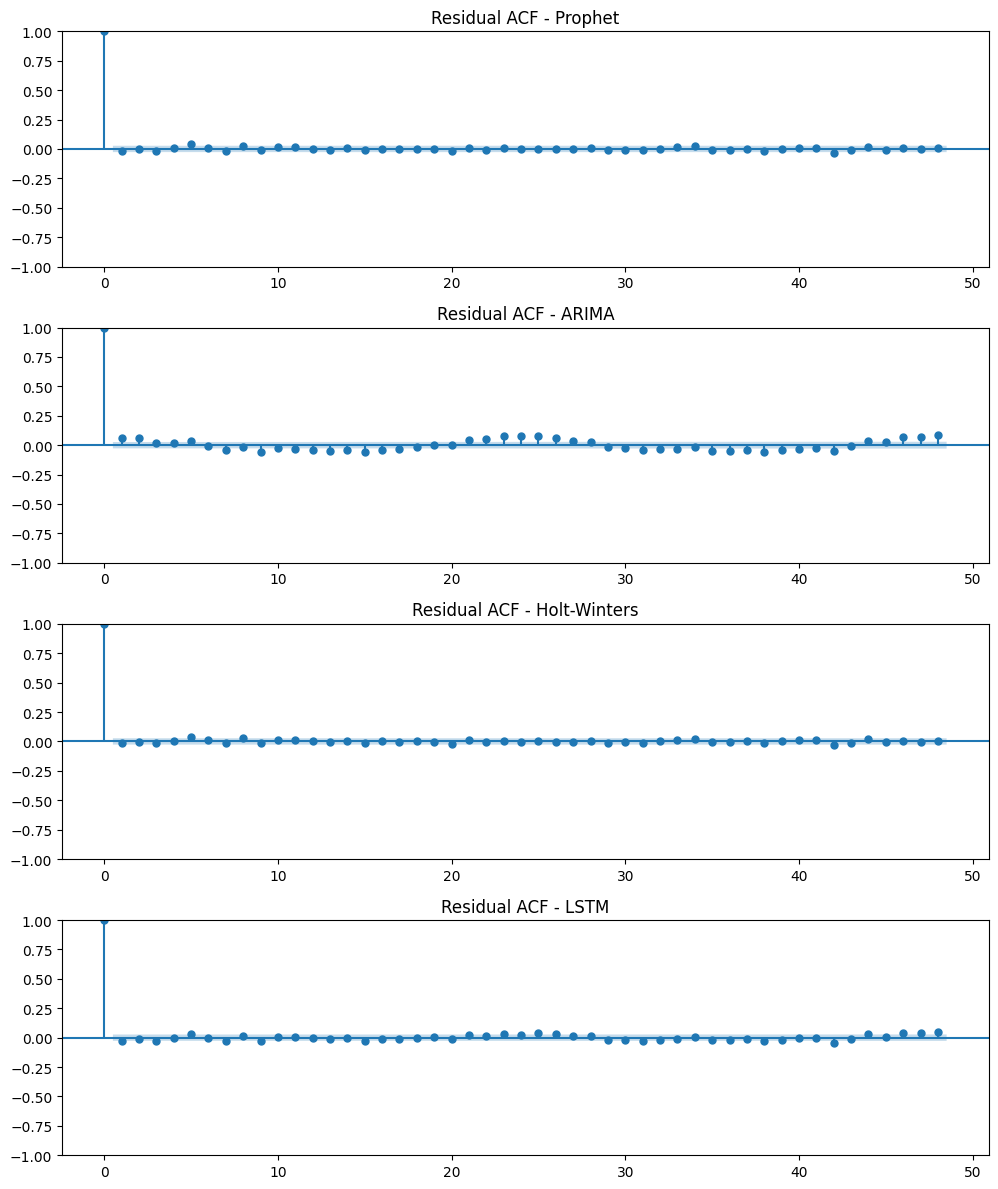

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(len(test_preds), 1, figsize=(10, 3*len(test_preds)))
for ax, (name, pred) in zip(axes, test_preds.items()):
    resid = y_test_rescaled - pred
    plot_acf(resid, lags=48, ax=ax, title=f"Residual ACF - {name}")
plt.tight_layout()
plt.show()

# Evaluation

In [ ]:
metrics = []
for name, pred in test_preds.items():
    rmse = root_mean_squared_error(y_test_rescaled, pred)
    mae = mean_absolute_error(y_test_rescaled, pred)
    metrics.append({"Model": name, "MAE": mae, "RMSE": rmse})

leaderboard = pd.DataFrame(metrics).sort_values("MAE").reset_index(drop=True)
print("=== MODEL LEADERBOARD (Ranked by MAE) ===")
print(leaderboard.to_string(index=False))

=== MODEL LEADERBOARD (Ranked by MAE) ===
       Model      MAE     RMSE
Holt-Winters 0.017122 0.021197
     Prophet 0.017212 0.021260
        LSTM 0.018061 0.021986
       ARIMA 0.018221 0.022184


# Select Best Model

In [ ]:
def model_leaderboard(test_preds, y_test_rescaled, mae_weight=0.5):

    metrics = []

    for name, pred in test_preds.items():

        mae = mean_absolute_error(
            y_test_rescaled,
            pred
        )

        rmse = root_mean_squared_error(
            y_test_rescaled,
            pred
        )

        metrics.append({
            "Model": name,
            "MAE": mae,
            "RMSE": rmse
        })

    leaderboard = pd.DataFrame(metrics)

    # Normalize MAE
    leaderboard["MAE_score"] = (
        (leaderboard["MAE"] - leaderboard["MAE"].min()) /
        (leaderboard["MAE"].max() - leaderboard["MAE"].min())
    )

    # Normalize RMSE
    leaderboard["RMSE_score"] = (
        (leaderboard["RMSE"] - leaderboard["RMSE"].min()) /
        (leaderboard["RMSE"].max() - leaderboard["RMSE"].min())
    )

    # Weight
    rmse_weight = 1 - mae_weight

    leaderboard["Combined_Score"] = (
        mae_weight * leaderboard["MAE_score"] +
        rmse_weight * leaderboard["RMSE_score"]
    )

    # Final ranking
    leaderboard = leaderboard.sort_values(
        ["Combined_Score", "MAE", "RMSE"]
    ).reset_index(drop=True)

    leaderboard["Final_Rank"] = (
        leaderboard.index + 1
    )

    # Reorder columns
    leaderboard = leaderboard[
        [
            "Final_Rank",
            "Model",
            "MAE",
            "RMSE",
            "MAE_score",
            "RMSE_score",
            "Combined_Score"
        ]
    ]

    return leaderboard

In [ ]:
leaderboard = model_leaderboard(
    test_preds,
    y_test_rescaled,
    mae_weight=0.5
)

print("=== FINAL MODEL LEADERBOARD ===")
print(leaderboard.to_string(index=False))

best_model_name = leaderboard.iloc[0]["Model"]
best_pred_test = test_preds[best_model_name]

print("\nBest Model:", best_model_name)

=== FINAL MODEL LEADERBOARD ===
 Final_Rank        Model      MAE     RMSE  MAE_score  RMSE_score  Combined_Score
          1 Holt-Winters 0.017122 0.021197   0.000000    0.000000        0.000000
          2      Prophet 0.017212 0.021260   0.081286    0.064251        0.072769
          3         LSTM 0.018061 0.021986   0.854416    0.799241        0.826829
          4        ARIMA 0.018221 0.022184   1.000000    1.000000        1.000000

Best Model: Holt-Winters


# Multi-Step Out-Of-Sample Forecast (Best Model Only)

In [ ]:
def forecast_future(
    best_model_name,
    final_models,
    forecast_hours,
    df,
    target_col,
    scaler,
    seq_len
):
    """
    Forecast future values using the selected best model.

    Parameters
    ----------
    best_model_name : str
        Name of the selected model.
    final_models : dict
        Dictionary containing the final fitted models.
    forecast_hours : int
        Number of future hours to forecast.
    df : pd.DataFrame
        Original dataframe.
    target_col : str
        Target column name.
    scaler : fitted MinMaxScaler
        Scaler used for the LSTM.
    seq_len : int
        Number of previous observations used by LSTM.

    Returns
    -------
    future_forecast : np.ndarray
        Forecasted values.
    """

    # ========================================================
    # LSTM
    # ========================================================

    if best_model_name == "LSTM":

        # Scale the full historical data
        full_scaled = scaler.transform(
            df[[target_col]].values
        )

        # Last SEQ_LEN observations as initial sequence
        last_seq = full_scaled[-seq_len:].copy()

        fc_list = []

        for _ in range(forecast_hours):

            p = final_models["LSTM"].predict(
                last_seq.reshape(1, seq_len, 1),
                verbose=0
            )[0][0]

            fc_list.append(p)

            # Move sequence forward
            last_seq = np.append(
                last_seq[1:],
                [[p]],
                axis=0
            )

        # Convert back to original fraud-rate scale
        future_forecast = scaler.inverse_transform(
            np.array(fc_list).reshape(-1, 1)
        ).flatten()


    # ========================================================
    # HOLT-WINTERS
    # ========================================================

    elif best_model_name == "Holt-Winters":

        future_forecast = final_models[
            "Holt-Winters"
        ].forecast(
            forecast_hours
        )


    # ========================================================
    # ARIMA
    # ========================================================

    elif best_model_name == "ARIMA":

        future_forecast = final_models[
            "ARIMA"
        ].forecast(
            steps=forecast_hours
        )


    # ========================================================
    # PROPHET
    # ========================================================

    elif best_model_name == "Prophet":

        future_dates_temp = pd.date_range(
            start=df["hour"].iloc[-1] + pd.Timedelta(hours=1),
            periods=forecast_hours,
            freq="h"
        )

        future_df = pd.DataFrame({
            "ds": future_dates_temp
        })

        future_forecast = final_models[
            "Prophet"
        ].predict(
            future_df
        )["yhat"].values


    else:
        raise ValueError(
            f"Unknown model: {best_model_name}"
        )

    return future_forecast

# Test Set Evaluation & Future Forecast for 24 Hours

In [ ]:
FORECAST_HOURS = 24

In [ ]:
future_forecast = forecast_future(
    best_model_name=best_model_name,
    final_models=final_models,
    forecast_hours=FORECAST_HOURS,
    df=df,
    target_col=target_col,
    scaler=scaler,
    seq_len=SEQ_LEN
)

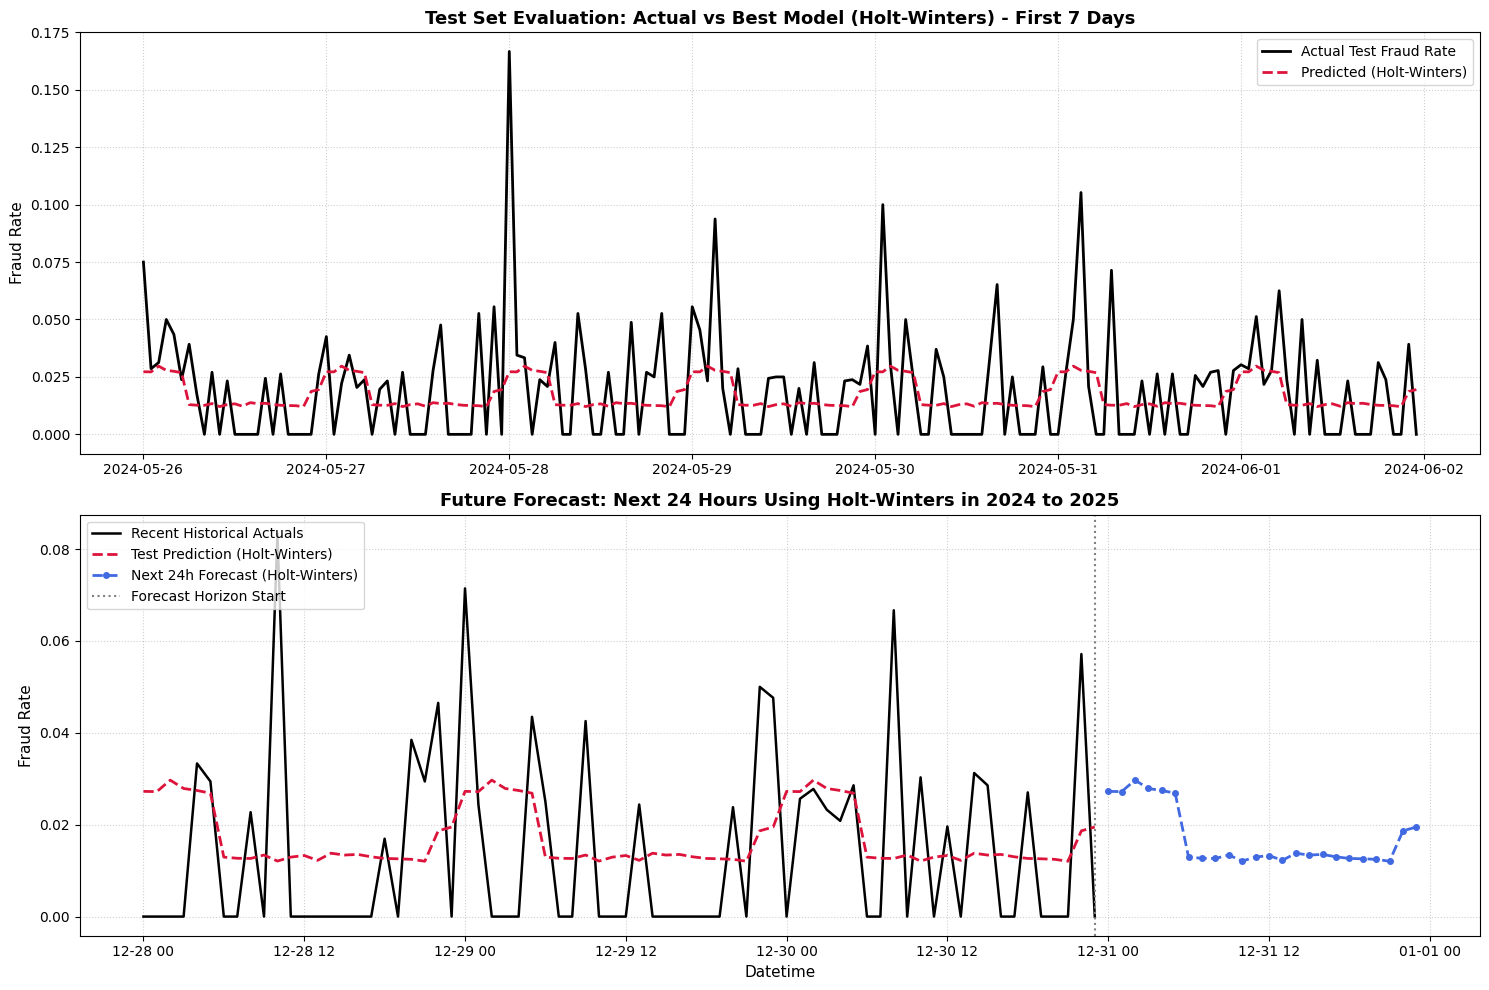

In [ ]:
last_date = df["hour"].iloc[-1]
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(hours=1), periods=FORECAST_HOURS, freq="h"
)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Subplot 1: Test Evaluation (First 168 hours for clean visual comparison)
zoom_hours = 168
axes[0].plot(
    test_dates[:zoom_hours],
    y_test_rescaled[:zoom_hours],
    label="Actual Test Fraud Rate",
    color="black",
    linewidth=2,
)
axes[0].plot(
    test_dates[:zoom_hours],
    best_pred_test[:zoom_hours],
    label=f"Predicted ({best_model_name})",
    color="crimson",
    linestyle="--",
    linewidth=2,
)
axes[0].set_title(
    f"Test Set Evaluation: Actual vs Best Model ({best_model_name}) - First 7 Days",
    fontsize=13,
    fontweight="bold",
)
axes[0].set_ylabel("Fraud Rate", fontsize=11)
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle=":", alpha=0.6)

# Subplot 2: Forward-Looking Out-of-Sample Forecast
context_hours = 72
# Ambil 72 jam terakhir dari TEST SET
test_dates_context = test_dates[-context_hours:]
test_pred_context = best_pred_test[-context_hours:]

# --- Recent historical actuals ---
axes[1].plot(
    df["hour"].iloc[-context_hours:],
    df[target_col].iloc[-context_hours:],
    label="Recent Historical Actuals",
    color="black",
    linewidth=1.8,
)

# --- Test set prediction (RED) ---
axes[1].plot(
    test_dates_context,
    test_pred_context,
    label=f"Test Prediction ({best_model_name})",
    color="crimson",
    linestyle="--",
    linewidth=2,
)

# --- Future 24-hour forecast (BLUE) ---
axes[1].plot(
    future_dates,
    future_forecast,
    label=f"Next {FORECAST_HOURS}h Forecast ({best_model_name})",
    color="royalblue",
    linestyle="--",
    marker="o",
    markersize=4,
    linewidth=2,
)
axes[1].axvline(
    last_date,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label="Forecast Horizon Start",
)
axes[1].set_title(
    f"Future Forecast: Next {FORECAST_HOURS} Hours Using {best_model_name} in 2024 to 2025",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_xlabel("Datetime", fontsize=11)
axes[1].set_ylabel("Fraud Rate", fontsize=11)
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
forecast_summary = pd.DataFrame(
    {
        "Hour": future_dates,
        f"Forecast_{best_model_name}": np.round(future_forecast, 5),
    }
)

print("\n=== Future 24-Hour Forecast Values ===")
print(forecast_summary.to_string(index=False))


=== Future 24-Hour Forecast Values ===
               Hour  Forecast_Holt-Winters
2024-12-31 00:00:00                0.02725
2024-12-31 01:00:00                0.02720
2024-12-31 02:00:00                0.02970
2024-12-31 03:00:00                0.02788
2024-12-31 04:00:00                0.02744
2024-12-31 05:00:00                0.02686
2024-12-31 06:00:00                0.01294
2024-12-31 07:00:00                0.01269
2024-12-31 08:00:00                0.01265
2024-12-31 09:00:00                0.01340
2024-12-31 10:00:00                0.01208
2024-12-31 11:00:00                0.01294
2024-12-31 12:00:00                0.01329
2024-12-31 13:00:00                0.01224
2024-12-31 14:00:00                0.01379
2024-12-31 15:00:00                0.01339
2024-12-31 16:00:00                0.01353
2024-12-31 17:00:00                0.01301
2024-12-31 18:00:00                0.01265
2024-12-31 19:00:00                0.01257
2024-12-31 20:00:00                0.01247
2024-12-31 21:

# Test Set Evaluation & Future Forecast for 72 Hours

In [ ]:
FORECAST_HOURS = 72

In [ ]:
future_forecast = forecast_future(
    best_model_name=best_model_name,
    final_models=final_models,
    forecast_hours=FORECAST_HOURS,
    df=df,
    target_col=target_col,
    scaler=scaler,
    seq_len=SEQ_LEN
)

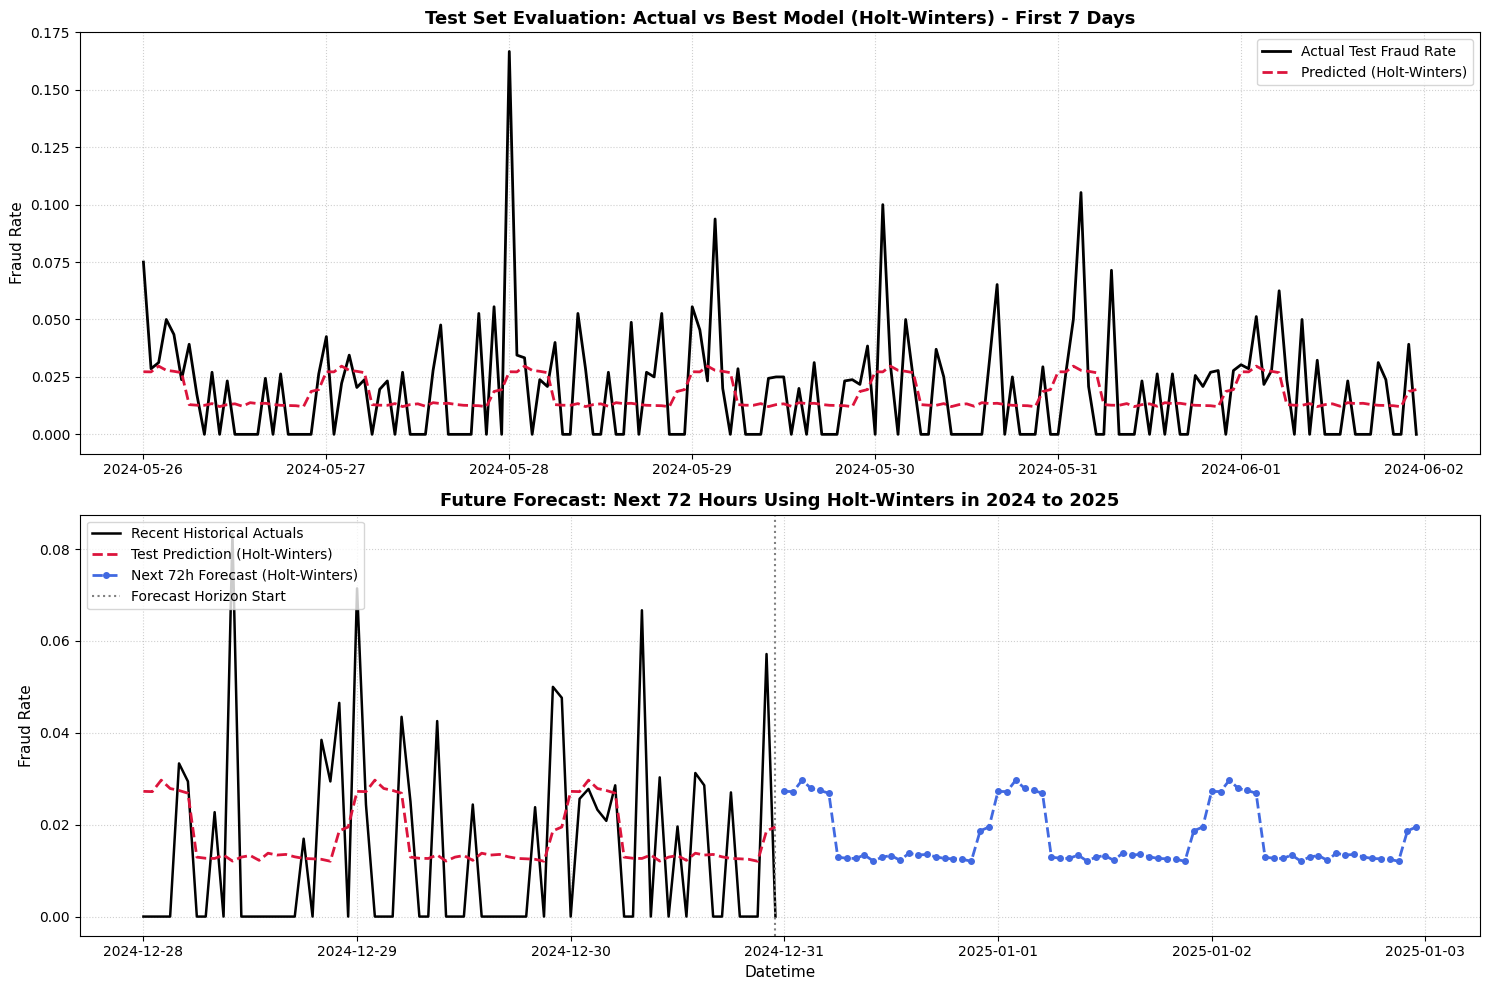

In [ ]:
last_date = df["hour"].iloc[-1]
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(hours=1), periods=FORECAST_HOURS, freq="h"
)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Subplot 1: Test Evaluation (First 168 hours for clean visual comparison)
zoom_hours = 168
axes[0].plot(
    test_dates[:zoom_hours],
    y_test_rescaled[:zoom_hours],
    label="Actual Test Fraud Rate",
    color="black",
    linewidth=2,
)
axes[0].plot(
    test_dates[:zoom_hours],
    best_pred_test[:zoom_hours],
    label=f"Predicted ({best_model_name})",
    color="crimson",
    linestyle="--",
    linewidth=2,
)
axes[0].set_title(
    f"Test Set Evaluation: Actual vs Best Model ({best_model_name}) - First 7 Days",
    fontsize=13,
    fontweight="bold",
)
axes[0].set_ylabel("Fraud Rate", fontsize=11)
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle=":", alpha=0.6)

# Subplot 2: Forward-Looking Out-of-Sample Forecast
context_hours = 72
# Ambil 72 jam terakhir dari TEST SET
test_dates_context = test_dates[-context_hours:]
test_pred_context = best_pred_test[-context_hours:]

# --- Recent historical actuals ---
axes[1].plot(
    df["hour"].iloc[-context_hours:],
    df[target_col].iloc[-context_hours:],
    label="Recent Historical Actuals",
    color="black",
    linewidth=1.8,
)

# --- Test set prediction (RED) ---
axes[1].plot(
    test_dates_context,
    test_pred_context,
    label=f"Test Prediction ({best_model_name})",
    color="crimson",
    linestyle="--",
    linewidth=2,
)

# --- Future 24-hour forecast (BLUE) ---
axes[1].plot(
    future_dates,
    future_forecast,
    label=f"Next {FORECAST_HOURS}h Forecast ({best_model_name})",
    color="royalblue",
    linestyle="--",
    marker="o",
    markersize=4,
    linewidth=2,
)
axes[1].axvline(
    last_date,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label="Forecast Horizon Start",
)
axes[1].set_title(
    f"Future Forecast: Next {FORECAST_HOURS} Hours Using {best_model_name} in 2024 to 2025",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_xlabel("Datetime", fontsize=11)
axes[1].set_ylabel("Fraud Rate", fontsize=11)
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

Ralat, kode di bawah ini seharusnya "Future 72-Hours Forecast Values"

In [ ]:
forecast_summary = pd.DataFrame(
    {
        "Hour": future_dates,
        f"Forecast_{best_model_name}": np.round(future_forecast, 5),
    }
)

print("\n=== Future 24-Hour Forecast Values ===")
print(forecast_summary.to_string(index=False))


=== Future 24-Hour Forecast Values ===
               Hour  Forecast_Holt-Winters
2024-12-31 00:00:00                0.02725
2024-12-31 01:00:00                0.02720
2024-12-31 02:00:00                0.02970
2024-12-31 03:00:00                0.02788
2024-12-31 04:00:00                0.02744
2024-12-31 05:00:00                0.02686
2024-12-31 06:00:00                0.01294
2024-12-31 07:00:00                0.01269
2024-12-31 08:00:00                0.01265
2024-12-31 09:00:00                0.01340
2024-12-31 10:00:00                0.01208
2024-12-31 11:00:00                0.01294
2024-12-31 12:00:00                0.01329
2024-12-31 13:00:00                0.01224
2024-12-31 14:00:00                0.01379
2024-12-31 15:00:00                0.01339
2024-12-31 16:00:00                0.01353
2024-12-31 17:00:00                0.01301
2024-12-31 18:00:00                0.01265
2024-12-31 19:00:00                0.01257
2024-12-31 20:00:00                0.01247
2024-12-31 21: